## Notebook overview

This notebook contains the implementation and experiments for the 1st assignment of the Text Analytics course.

The notebook is divided into two main parts:
- **Part A - Exercise 2:**  
  Implementation of the Levenshtein distance algorithm using dynamic programming, along with vocabulary based word matching using edit distance thresholds
- **Part B - Exercise 3:**  
  Implementation of bigram and trigram language models using Laplace smoothing, evaluation using cross-entropy and perplexity, sentence completion experiments using different decoding methods (greedy decoding, beam search, and Top-K sampling)

# Part A - Exercise 2: Levenshtein Distance

In this part, the Levenshtein distance algorithm was implemented. The implementation computes the minimum edit distance between two words and prints the corresponding table.

The implementation was then extended in order to compare an input word against a vocabulary and return all vocabulary words whose Levenshtein distance is smaller than or equal to a selected threshold.

The experiments demonstrate how edit distance can be used for approximate string matching and spelling correction tasks.

The following function implements the Levenshtein distance algorithm using a bottom-up dynamic programming approach.
It initialises a matrix of size (n+1)×(m+1), fills it row by row according to the edit cost rules,
and returns both the full distance matrix and the final distance value.

In [ ]:
# (i) Levenshtein Distance function

def levenshtein(word_1, word_2):
    n = len(word_1)
    m = len(word_2)

    # Creating a table (n+1) x (m+1)
    dp = [[0] * (m + 1) for _ in range(n + 1)]

    # First column: cost of deleting all characters of word1[:i] to reach empty string
    for i in range(n + 1):
        dp[i][0] = i

    # First row: cost of inserting all characters to go from empty string to word2[:j]
    for j in range(m + 1):
        dp[0][j] = j

    # Fill in the rest of the table
    for i in range(1, n + 1):
        for j in range(1, m + 1):
            if word_1[i-1] == word_2[j-1]:
                # Same character → take diagonal value for free (cost 0)
                dp[i][j] = dp[i-1][j-1]
            else:
                dp[i][j] = min(
                    dp[i-1][j]   + 1,  # Delete: remove word1[i-1], solve rest
                    dp[i][j-1]   + 1,  # Insert: insert word2[j-1] into word1, solve rest
                    dp[i-1][j-1] + 2   # Replace: swap word1[i-1] for word2[j-1] (cost 2)
                )
    # Return the full table and the final distance (bottom-right cell)
    return dp, dp[n][m]




The following helper function formats and prints the distance matrix in a readable tabular form,
with row and column labels for each character of the two input strings.

In [ ]:
def print_table(str1, str2, dp):
    # Print header row: empty cell, "#" for empty string, then each char of word 2
    header = ["", "#"] + list(str2)
    print("\t".join(header))

    # Print each row: label is "#" for row 0, then each char of word 1
    row_labels = ["#"] + list(str1)
    for i, label in enumerate(row_labels):
        row = [label] + [str(dp[i][j]) for j in range(len(str2) + 1)]
        print("\t".join(row))


Both functions are tested on five representative word pairs, covering cases such as
British/American spelling variants, case sensitivity, prefix relationships, and fully dissimilar strings.

In [ ]:
# --- TEST CASES ---

test_cases = [
    ("colour", "color"),
    ("dog", "cat"),
    ("Rain", "raining"),
    ("hello", "Hello"),
    ("python", "java"),
]


for word_1, word_2 in test_cases:
    dp, dist = levenshtein(word_1, word_2)
    print(f"word1='{word_1}', \nword2='{word_2}'\n")
    print(f"Levenshtein distance: {dist}\n")
    print_table(word_1, word_2, dp)
    print("\n" + "-" * 50 + "\n")

word1='colour', 
word2='color'

Levenshtein distance: 1

	#	c	o	l	o	r
#	0	1	2	3	4	5
c	1	0	1	2	3	4
o	2	1	0	1	2	3
l	3	2	1	0	1	2
o	4	3	2	1	0	1
u	5	4	3	2	1	2
r	6	5	4	3	2	1

--------------------------------------------------

word1='dog', 
word2='cat'

Levenshtein distance: 6

	#	c	a	t
#	0	1	2	3
d	1	2	3	4
o	2	3	4	5
g	3	4	5	6

--------------------------------------------------

word1='Rain', 
word2='raining'

Levenshtein distance: 5

	#	r	a	i	n	i	n	g
#	0	1	2	3	4	5	6	7
R	1	2	3	4	5	6	7	8
a	2	3	2	3	4	5	6	7
i	3	4	3	2	3	4	5	6
n	4	5	4	3	2	3	4	5

--------------------------------------------------

word1='hello', 
word2='Hello'

Levenshtein distance: 2

	#	H	e	l	l	o
#	0	1	2	3	4	5
h	1	2	3	4	5	6
e	2	3	2	3	4	5
l	3	4	3	2	3	4
l	4	5	4	3	2	3
o	5	6	5	4	3	2

--------------------------------------------------

word1='python', 
word2='java'

Levenshtein distance: 10

	#	j	a	v	a
#	0	1	2	3	4
p	1	2	3	4	5
y	2	3	4	5	6
t	3	4	5	6	7
h	4	5	6	7	8
o	5	6	7	8	9
n	6	7	8	9	10

------------------------------------------------

The results confirm that the algorithm correctly computes the Levenshtein distance for all test pairs.
Notable observations include the effect of case sensitivity (e.g. 'Rain' vs. 'raining', 'hello' vs. 'Hello')
and the expected behaviour for fully dissimilar strings (e.g. 'python' vs. 'java', distance = 10).
The output tables allow direct verification of all intermediate values against the reference tool
provided in the exercise specification (http://www.let.rug.nl/~kleiweg/lev/).

### Vocabulary Retrieval

In this section, the implementation is extended to support vocabulary-based retrieval.
The vocabulary is constructed from the Brown Corpus via NLTK, retaining only words that appear at least 10 times.

In [ ]:
# (ii)

import nltk
from collections import Counter

nltk.download('brown')
from nltk.corpus import brown

# Load all words from Brown corpus in lowercase
all_words = [w.lower() for w in brown.words()]

# Count word frequencies
freq = Counter(all_words)

# Keep only words that appear >= 10 times
V = [word for word, count in freq.items() if count >= 10]
print(f"Vocabulary size: {len(V)} words")

[nltk_data] Downloading package brown to /root/nltk_data...
[nltk_data]   Package brown is already up-to-date!


Vocabulary size: 8504 words


The following function accepts a query word, a vocabulary, and a maximum distance threshold.
It returns all vocabulary words whose Levenshtein distance from the query does not exceed the threshold,
sorted by distance in ascending order.

In [ ]:
# Function: Find words in V within distance d from word w
def find_close_words(w, V, d):
    w = w.lower()
    results = []

    for vocab_word in V:
        _, dist = levenshtein(w, vocab_word)
        if dist <= d:
            results.append((vocab_word, dist))

    # Sort by distance (closest first)
    results.sort(key=lambda x: x[1])
    return results


The function is tested using 'colour' as a query word across four distance thresholds (d = 1, 2, 3, 5),
demonstrating how the result set grows as the threshold increases.

In [ ]:
# --- TESTS ---
test_cases = [
    ("colour", 1),   # only very close words
    ("colour", 2),   # a bit looser
    ("colour", 3),   # even looser
    ("colour", 5),   # very loose
]

for word, d in test_cases:
    close = find_close_words(word, V, d)
    print(f"\nWords close to '{word}' with distance <= {d}:")
    for w, dist in close:
        print(f"  {w}  (distance={dist})")
    print(f"  Total: {len(close)} words found")


Words close to 'colour' with distance <= 1:
  color  (distance=1)
  Total: 1 words found

Words close to 'colour' with distance <= 2:
  color  (distance=1)
  colors  (distance=2)
  Total: 2 words found

Words close to 'colour' with distance <= 3:
  color  (distance=1)
  colors  (distance=2)
  court  (distance=3)
  our  (distance=3)
  lou  (distance=3)
  cloud  (distance=3)
  colored  (distance=3)
  Total: 7 words found

Words close to 'colour' with distance <= 5:
  color  (distance=1)
  colors  (distance=2)
  court  (distance=3)
  our  (distance=3)
  lou  (distance=3)
  cloud  (distance=3)
  colored  (distance=3)
  or  (distance=4)
  four  (distance=4)
  courts  (distance=4)
  poor  (distance=4)
  cook  (distance=4)
  your  (distance=4)
  hour  (distance=4)
  closer  (distance=4)
  core  (distance=4)
  club  (distance=4)
  course  (distance=4)
  ours  (distance=4)
  lord  (distance=4)
  cold  (distance=4)
  loud  (distance=4)
  column  (distance=4)
  tour  (distance=4)
  colorado  (di

The results confirm that the retrieval function correctly scales its output with the chosen threshold.
At tighter thresholds, only very close variants are returned (e.g. 'color' at d = 1),
while looser thresholds retrieve a broader set of lexically similar words (125 words at d = 5),
demonstrating the practical applicability of edit distance for fuzzy vocabulary search.

# Part B - Exercise 3: Bigram and Trigram Language Models

In this part bigram and trigram language models were implemented using Laplace smoothing. The models were trained on a subset of the NLTK mystery corpus after preprocessing, tokenization, vocabulary construction and out-of-vocabulary word replacement using the special token \*UNK\*.

The implementation includes:
- training of bigram and trigram language models
- computation of sentence probabilities using log-probabilities
- evaluation using cross-entropy and perplexity
- sentence completion experiments using different decoding methods (greedy decoding, beam search decoding, top-K sampling)


The experiments examine the quality, fluency, diversity and stability of the generated sentence completions for both the bigram and trigram models

## Part (i) - Bigram and Trigram Language Model implementation

- In this part bigram and trigram language models are implemented using Laplace smoothing.
- The models are trained on the mystery category of the Brown corpus from NLTK.

### Dataset and preprocessing

- The Brown corpus from NLTK is used as the training corpus for the language models. Specifically the mystery category is selected for the experiments
- The corpus is loaded as a list of tokenized sentences, where each sentence is represented as a list of words and punctuation symbols

In [ ]:
import nltk
from collections import Counter

nltk.download('brown')
from nltk.corpus import brown

[nltk_data] Downloading package brown to /root/nltk_data...
[nltk_data]   Package brown is already up-to-date!


In [ ]:
print(brown.categories())

['adventure', 'belles_lettres', 'editorial', 'fiction', 'government', 'hobbies', 'humor', 'learned', 'lore', 'mystery', 'news', 'religion', 'reviews', 'romance', 'science_fiction']


In [ ]:
all_sentences = brown.sents(categories='mystery') # list of lists where each list contains the words
# and chars of the sentence
len(all_sentences) # 3886 sentences

3886

In [ ]:
all_sentences

[['There', 'were', 'thirty-eight', 'patients', 'on', 'the', 'bus', 'the', 'morning', 'I', 'left', 'for', 'Hanover', ',', 'most', 'of', 'them', 'disturbed', 'and', 'hallucinating', '.'], ['An', 'interne', ',', 'a', 'nurse', 'and', 'two', 'attendants', 'were', 'in', 'charge', 'of', 'us', '.'], ...]

In [ ]:
print(f"first sentence: {all_sentences[0]}")

first sentence: ['There', 'were', 'thirty-eight', 'patients', 'on', 'the', 'bus', 'the', 'morning', 'I', 'left', 'for', 'Hanover', ',', 'most', 'of', 'them', 'disturbed', 'and', 'hallucinating', '.']


- All words are converted to lowercase in order to reduce vocabulary size and ensure consistent word representations during training

In [ ]:
all_sentences = [[w.lower() for w in sent] for sent in all_sentences] # convert to lowercase

- The dataset is divided into training and test subsets
- The training set will be used for estimating the n-gram probabilities, while the test set will be used for evaluation through cross-entropy and perplexity

In [ ]:
# train-test split
train_set = all_sentences[:int(0.8 * len(all_sentences))]
test_set = all_sentences[int(0.8 * len(all_sentences)):]

print(len(train_set)) # 3108
print(len(test_set)) # 778

3108
778


- The vocabulary was constructed using only the training set in order to avoid using information from the test data during training
- Words that appeared very few times were excluded from the final vocabulary and later replaced with the special token \*UNK\*
- Different minimum frequency thresholds were tested before selecting the final vocabulary. A threshold of 10 was finally selected following the assignment instructions, because it removes many rare words while still keeping enough vocabulary coverage for the language models. This also helps reduce sparsity in the n-gram counts

In [ ]:
word_counts = Counter(w for sent in train_set for w in sent) # as a vocab keep only the words that appear 10 or more times in the training set
# we use the training set to get the vocab from in order for the test set to include unseen also words
print(word_counts)
vocab = {w for w, c in word_counts.items() if c >= 10}
vocab.add('*UNK*')
vocab.add('*end*')
print(len(vocab)) # 528
vocab_try = {w for w, c in word_counts.items() if c==1}
print(len(vocab_try)) # 3101 we have a lot of words that appear only once
vocab_try = {w for w, c in word_counts.items() if c>1 and c<=5}
print(len(vocab_try)) # 1707 words with freq (1,5]
vocab_try = {w for w, c in word_counts.items() if c>5 and c<10}
print(len(vocab_try)) # 355 words with freq (5,10)

Counter({'.': 2646, 'the': 2288, ',': 2241, 'to': 1083, 'and': 1030, 'a': 939, 'he': 903, 'of': 732, 'was': 673, '``': 607, "''": 604, 'in': 574, '?': 558, 'it': 521, 'his': 463, 'had': 452, 'that': 437, 'i': 404, 'on': 354, 'you': 331, 'she': 315, 'for': 307, 'at': 279, 'her': 270, 'him': 269, 'with': 267, 'as': 235, '--': 214, 'be': 209, 'but': 204, ';': 200, 'up': 189, 'there': 185, 'not': 184, 'out': 174, 'have': 172, 'said': 169, 'would': 164, 'no': 152, 'from': 147, 'this': 143, 'all': 142, 'they': 136, 'if': 127, 'back': 127, 'one': 126, 'could': 125, 'into': 125, 'were': 121, 'been': 119, 'what': 118, 'when': 117, 'like': 115, 'then': 113, 'or': 105, 'about': 101, 'so': 101, 'an': 99, 'them': 96, 'by': 94, 'over': 92, 'now': 89, 'me': 88, 'do': 84, 'is': 84, 'my': 83, 'man': 81, 'who': 81, 'just': 76, 'get': 75, 'two': 72, 'door': 72, "don't": 70, 'go': 70, 'some': 68, 'down': 68, 'got': 67, 'around': 67, 'more': 66, 'time': 66, 'here': 65, 'off': 65, 'car': 65, 'too': 62, 'kno

/tmp/ipykernel_10535/921991228.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Frequency Range', y='Number of Words', palette='Blues_d')


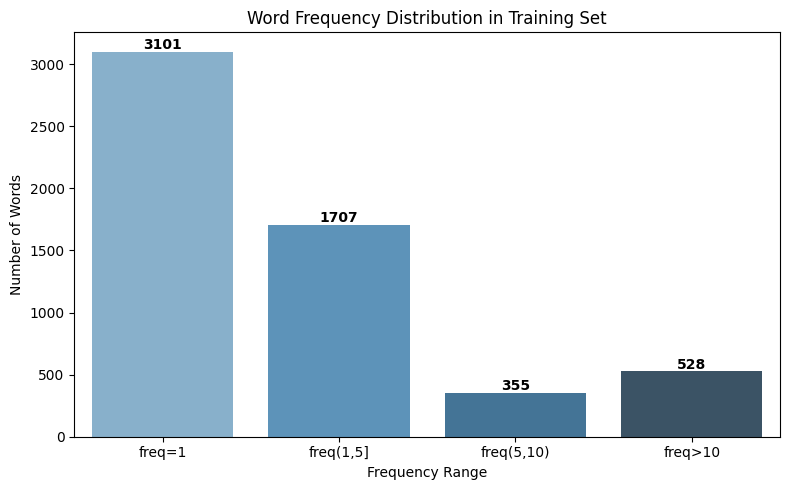

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

freq_ranges = {
    'freq=1': len({w for w, c in word_counts.items() if c == 1}),
    'freq(1,5]': len({w for w, c in word_counts.items() if c > 1 and c <= 5}),
    'freq(5,10)': len({w for w, c in word_counts.items() if c > 5 and c < 10}),
    'freq>10': len({w for w, c in word_counts.items() if c >= 10})
}

df = pd.DataFrame(list(freq_ranges.items()), columns=['Frequency Range', 'Number of Words'])

plt.figure(figsize=(8, 5))
sns.barplot(data=df, x='Frequency Range', y='Number of Words', palette='Blues_d')
plt.title('Word Frequency Distribution in Training Set')
plt.xlabel('Frequency Range')
plt.ylabel('Number of Words')
for i, v in enumerate(df['Number of Words']):
    plt.text(i, v + 20, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

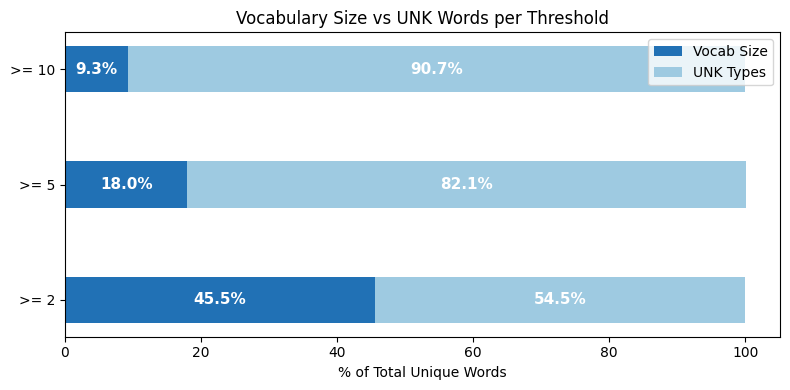

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

total_unique = len(word_counts)
thresholds = [2, 5, 10]

vocab_pcts = []
unk_pcts = []

for t in thresholds:
    vocab = {w for w, c in word_counts.items() if c >= t}
    vocab.add('*UNK*')
    vocab.add('*end*')
    unk_words = {w for w, c in word_counts.items() if c < t}
    vocab_pcts.append(round(100 * len(vocab) / total_unique, 1))
    unk_pcts.append(round(100 * len(unk_words) / total_unique, 1))

labels = [f'>= {t}' for t in thresholds]
x = np.arange(len(labels))
height = 0.4

fig, ax = plt.subplots(figsize=(8, 4))

bars1 = ax.barh(x, vocab_pcts, height, label='Vocab Size', color='#2171b5')
bars2 = ax.barh(x, unk_pcts, height, left=vocab_pcts, label='UNK Types', color='#9ecae1')

for bar, val in zip(bars1, vocab_pcts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_y() + bar.get_height()/2,
            f'{val}%', ha='center', va='center', color='white', fontsize=11, fontweight='bold')

for bar, val in zip(bars2, unk_pcts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_y() + bar.get_height()/2,
            f'{val}%', ha='center', va='center', color='white', fontsize=11, fontweight='bold')

ax.set_yticks(x)
ax.set_yticklabels(labels)
ax.set_xlabel('% of Total Unique Words')
ax.set_title('Vocabulary Size vs UNK Words per Threshold')
ax.legend()
plt.tight_layout()
plt.show()

- After constructing the vocabulary, all words not contained in the vocabulary were replaced with the \*UNK\* token in the training and test sets

In [ ]:
# replace out-of-vocabulary words with token unk and vocab is build only for the train set
# as sheeen before thas the unk will be decided based only on the train set words
def replace_oov(sentences, vocab):
    return [[w if w in vocab else '*UNK*' for w in sent] for sent in sentences]

train_sents = replace_oov(train_set, vocab)
test_sents = replace_oov(test_set, vocab)

In [ ]:
print(any('*UNK*' in sent for sent in train_sents))
print(any('*UNK*' in sent for sent in test_sents))

True
True


Special boundary tokens were added to the sentences before training the language models.
- For the bigram model one `*start*` token was added at the beginning of each sentence, while for the trigram model two `*start*` tokens were added so that the model has enough initial context for the first prediction
- In both models the `*end*` token was added at the end of each sentence so that the models can learn when a sentence is likely to finish

The following examples show the final sentence representation after preprocessing, OOV replacement and insertion of boundary tokens

In [ ]:
# add start and end token
def add_boundary_tokens(sentences, n=2): # n=2 for bigram and n=3 for trigram
    padded = []
    for sent in sentences:
        starts = ['*start*'] * (n - 1)
        padded.append(starts + sent + ['*end*'])
    return padded

train_bigram = add_boundary_tokens(train_sents, n=2)
train_trigram = add_boundary_tokens(train_sents, n=3) # for trigram we need 2 start tokens cause the
# trigram models this: P(w₃ | w₁, w₂) meaning it need 2 words to predict the existence of the first
# word in the sentence. For the bigram, it goes accordingly, P(w₂| w₁).

print(train_bigram)
print(train_trigram)

[['*start*', 'there', 'were', '*UNK*', '*UNK*', 'on', 'the', '*UNK*', 'the', 'morning', 'i', 'left', 'for', '*UNK*', ',', 'most', 'of', 'them', '*UNK*', 'and', '*UNK*', '.', '*end*'], ['*start*', 'an', '*UNK*', ',', 'a', '*UNK*', 'and', 'two', '*UNK*', 'were', 'in', '*UNK*', 'of', 'us', '.', '*end*'], ['*start*', 'i', 'felt', '*UNK*', 'and', '*UNK*', 'as', 'i', 'stared', 'out', 'the', '*UNK*', 'window', 'at', '*UNK*', '*UNK*', ',', '*UNK*', '*UNK*', 'side', '.', '*end*'], ['*start*', 'it', 'seemed', '*UNK*', ',', 'as', 'i', '*UNK*', 'to', 'the', '*UNK*', '*UNK*', 'of', '*UNK*', 'and', '*UNK*', 'the', '*UNK*', '*UNK*', 'coming', 'from', 'the', '*UNK*', ',', 'that', '*UNK*', 'i', 'was', 'a', '*UNK*', 'of', 'the', '*UNK*', 'of', '*UNK*', ',', 'going', 'to', 'a', '*UNK*', 'for', 'the', '*UNK*', '*UNK*', '.', '*end*'], ['*start*', 'i', 'suddenly', 'thought', 'of', '*UNK*', '*UNK*', '*UNK*', ',', 'the', 'way', 'her', 'pretty', 'eyes', 'could', '*UNK*', 'with', '*UNK*', ',', 'her', '*UNK*', '

### N-gram model training (bigram and trigram)

- Before training the full models a small example is shown using only a few sentences from the training set. This helps demonstrate how unigram, bigram and trigram counts are created and how n-gram probabilities are estimated from the corpus

In [ ]:
from nltk.util import ngrams

# get 2 first sentences form train set
example_sents = train_sents[:2]

print("sentence 1:", example_sents[0])
print("sentence 2:", example_sents[1])

# boundary tokens
example_bigram = add_boundary_tokens(example_sents, n=2)
example_trigram = add_boundary_tokens(example_sents, n=3)

print("bigram sentences:", example_bigram)
print("trigram sentences:", example_trigram)

ex_unigram = Counter()
ex_bigram = Counter()
ex_trigram = Counter()

for sent in example_bigram:
    ex_unigram.update([(w,) for w in sent])
    ex_bigram.update(ngrams(sent, 2))

for sent in example_trigram:
    ex_trigram.update(ngrams(sent, 3))

ex_bigram[('*start*', '*start*')] = len(example_sents)

print("unigram counts:")
print(dict(ex_unigram))

print("bigram counts:")
print(dict(ex_bigram))

print("trigram counts:")
print(dict(ex_trigram))

# P("there"|<s>) for bigram
# P("there"|<s>) = count(<s>, "there")/count(<s>)
p_there_given_start = ex_bigram[('*start*', 'there')] / ex_unigram[('*start*',)]
print(f"P('there' | '*start*') = {ex_bigram[('*start*', 'there')]} / {ex_unigram[('*start*',)]} = {p_there_given_start:.2f}")

# P("there"|<s>,<s>) for trigram
# P("there"|<s>,<s>) = count(<s>,<s>,"there")/count(<s>, <s>)
p_there_given_2starts = ex_trigram[('*start*', '*start*', 'there')] / ex_bigram[('*start*', '*start*')]
print(f"P('there' | '*start*','*start*') = {ex_trigram[('*start*', '*start*', 'there')]} / {ex_bigram[('*start*', '*start*')]} = {p_there_given_2starts:.2f}")

sentence 1: ['there', 'were', '*UNK*', '*UNK*', 'on', 'the', '*UNK*', 'the', 'morning', 'i', 'left', 'for', '*UNK*', ',', 'most', 'of', 'them', '*UNK*', 'and', '*UNK*', '.']
sentence 2: ['an', '*UNK*', ',', 'a', '*UNK*', 'and', 'two', '*UNK*', 'were', 'in', '*UNK*', 'of', 'us', '.']
bigram sentences: [['*start*', 'there', 'were', '*UNK*', '*UNK*', 'on', 'the', '*UNK*', 'the', 'morning', 'i', 'left', 'for', '*UNK*', ',', 'most', 'of', 'them', '*UNK*', 'and', '*UNK*', '.', '*end*'], ['*start*', 'an', '*UNK*', ',', 'a', '*UNK*', 'and', 'two', '*UNK*', 'were', 'in', '*UNK*', 'of', 'us', '.', '*end*']]
trigram sentences: [['*start*', '*start*', 'there', 'were', '*UNK*', '*UNK*', 'on', 'the', '*UNK*', 'the', 'morning', 'i', 'left', 'for', '*UNK*', ',', 'most', 'of', 'them', '*UNK*', 'and', '*UNK*', '.', '*end*'], ['*start*', '*start*', 'an', '*UNK*', ',', 'a', '*UNK*', 'and', 'two', '*UNK*', 'were', 'in', '*UNK*', 'of', 'us', '.', '*end*']]
unigram counts:
{('*start*',): 2, ('there',): 1, ('

- After verifying the counting process on a small example, unigram, bigram and trigram counts are collected for the full training set
- These counts are later used to compute the smoothed n-gram probabilities of the language models

In [ ]:
from tqdm import tqdm
from nltk.util import ngrams

# in order to calculate the probabilities, we need to calculate the counting appearances of each
# word and combination of words in the train set . we need to calculate the unigram and bigram (
# and later trigram counts)
# for example from our vocab: P("attendants"|"two") = count("the","attendants")/count("two")
# we want to do the above mentioned procedure but for all sentences

unigram_counter = Counter()
bigram_counter = Counter()
trigram_counter = Counter()


for sent in tqdm(train_bigram):
    unigram_counter.update([(w,) for w in sent])
    bigram_counter.update(ngrams(sent, 2))

for sent in tqdm(train_trigram):
    trigram_counter.update(ngrams(sent, 3))

bigram_counter[('*start*', '*start*')] = len(train_sents) # bigram contains only one <s> thus the count('<s>', '<s>')
# cannot be calculated there, and it is needed for the calculation of
# P(word | <s>, <s>) = count('<s>', '<s>', word) / count('<s>', '<s>')

100%|██████████| 3108/3108 [00:00<00:00, 51924.05it/s]


## Part (ii) - Cross-entropy and Perplexity evaluation

In this part the bigram and trigram language models are evaluated on the test set using cross-entropy and perplexity. These metrics measure how well each model predicts unseen text.

- Log-probabilities are used instead of directly multiplying probabilities because sentence probabilities quickly become extremely small

### N-gram probability functions

- The following functions compute Laplace-smoothed bigram and trigram probabilities
- A helper function is also defined to convert probabilities into log-probabilities

In [ ]:
import math
START = "*start*"
END = "*end*"
UNK = "*UNK*"
ALPHA = 1.0
VOCAB_SIZE = len(vocab)

def bigram_prob(prev_word, word):
    """Compute Laplace-smoothed bigram probability."""

    # for w_i the prob is calculated as:
    # numerator: how many times word w_{i-1} was followed by w_i + 1 (smoothing) /
    # denominator: how many times w_{i-1} appeared + |V| (smoothing)
    numerator = bigram_counter[(prev_word, word)] + ALPHA
    denominator = unigram_counter[(prev_word,)] + ALPHA * VOCAB_SIZE

    return numerator/denominator


def trigram_prob(word1, word2, word3):
    """Compute Laplace-smoothed trigram probability"""

    # P(w_i | w_{i-2}, w_{i-1}) with Laplace smoothing
    # numerator: how many times (w_{i-2}, w_{i-1}) was followed by w_i + 1 (smoothing)
    # denominator: how many times bigram (w_{i-2}, w_{i-1}) appeared + |V| (smoothing)
    numerator = trigram_counter[(word1, word2, word3)] + ALPHA
    denominator = bigram_counter[(word1, word2)] + ALPHA * VOCAB_SIZE

    return numerator/denominator

def get_prob(context, word, model_type, use_log=False):
    """Return probability or log-probability for a candidate next word"""

    if model_type == "bigram":
        prob = bigram_prob(context[-1], word)

    elif model_type == "trigram":
        prob = trigram_prob(context[-2], context[-1], word)
    else:
        raise ValueError("model_type must be 'bigram' or 'trigram'")

    if use_log:
      return math.log2(prob)
    return prob

### Bigram Language Model evaluation

- The following function computes the cross-entropy and perplexity of the bigram language model using Laplace smoothing
- For each word, the model estimates the probability of the current word given the previous word.

In [ ]:
def bigram_LM(corpus, unigram_counter, bigram_counter, alpha=1.0):
    # with laplace smoothing, redistributes probability mass to unseen bigrams in order to avoid
    # zero probabilities

    sum_log_prob = 0
    token_count = 0
    vocab_size = len(vocab)

    for sent in corpus:
        # add start and end tokens for each sentence
        sent = ['*start*'] + sent + ['*end*']

        for idx in range(1, len(sent)):
            # skip <s> token — we never predict the start token, only predict from it
            if sent[idx] == '*start*':
                continue

            context = [sent[idx - 1]]
            # we sum log probabilities instead of multiplying probabilities
            # becausemultiplying many small numbers could cause underflow -from paris lessons ;)
            # - (too small for computer)
            # log turns products into sums: log(a*b) = log(a) + log(b)
            sum_log_prob += get_prob(context, sent[idx], model_type="bigram", use_log=True)
            token_count  += 1  # we count <e> tokens but not <s> tokens
    # cross entropy = average negative log probability per token H=(−1/N)*∑logP(wi​∣context) for i in [1,N]
    cross_entropy = -sum_log_prob / token_count
    # perplexity: how "surprised" the model is = exp(H)
    perplexity = math.pow(2, cross_entropy)
    print(f"Bigram - Cross Entropy: {cross_entropy:.3f}  Perplexity: {perplexity:.3f}")
    return cross_entropy, perplexity


### Trigram Language Model Evaluation

- The following function computes the cross-entropy and perplexity of the trigram language model using Laplace smoothing
- In the trigram model, each word is predicted using the two previous words as context. This allows the model to capture more local context compared to the bigram model

In [ ]:
def trigram_LM(corpus, unigram_counter, bigram_counter, trigram_counter, alpha=1.0):
    # with laplace smoothing, redistributes probability mass to unseen trigrams in order to avoid
    # zero probabilities

    sum_log_prob = 0
    token_count = 0
    vocab_size = len(vocab)

    for sent in corpus:
        # two <s> tokens for trigram — need 2 words of context for the first word
        sent = ['*start*', '*start*'] + sent + ['*end*']

        for idx in range(2, len(sent)):
            # skip <s> token — we never predict the start token, only predict from it
            if sent[idx] == '*start*':
                continue

            context = [sent[idx - 2], sent[idx - 1]]

            # same reasoning as bigram, sum logs to avoid underflow
            sum_log_prob += get_prob(context, sent[idx], model_type="trigram", use_log=True)
            token_count += 1  # we count <e> tokens but not <s> tokens

    # cross entropy = average negative log probability per token
    cross_entropy = -sum_log_prob / token_count
    # perplexity: how "surprised" the model is = exp(H)
    perplexity = math.pow(2, cross_entropy)
    print(f"Trigram - Cross Entropy: {cross_entropy:.3f}  Perplexity: {perplexity:.3f}")
    return cross_entropy, perplexity

- The bigram model is first evaluated on the training set in order to check how well it fits the data it was trained on

In [ ]:
bigram_LM(train_sents, unigram_counter, bigram_counter)

Bigram - Cross Entropy: 5.464  Perplexity: 44.137


(5.463910376044722, 44.13680752041555)

- The same evaluation is then performed on the test set using unseen sentences
- Comparing the training and test results helps show how well the model generalizes to new data

In [ ]:
bigram_LM(test_sents, unigram_counter, bigram_counter)

Bigram - Cross Entropy: 5.579  Perplexity: 47.803


(5.579018199000397, 47.80263363421574)

- The trigram model is also evaluated on the training set
- Since the trigram model uses two previous words as context, it can capture more local information compared to the bigram model.

In [ ]:
trigram_LM(train_sents, unigram_counter, bigram_counter, trigram_counter)

Trigram - Cross Entropy: 6.527  Perplexity: 92.251


(6.527491596869419, 92.25093298230098)

- Finally the trigram model is evaluated on the unseen test set

In [ ]:
trigram_LM(test_sents, unigram_counter, bigram_counter, trigram_counter)

Trigram - Cross Entropy: 6.944  Perplexity: 123.164


(6.944434826484029, 123.16383002807035)

In [ ]:
# Sparsity analysis: how many n grams appear only once in the training corpus?
# A high percentage of these  trigrams indicates severe data sparsity,
# meaning the model has not seen enough data to learn reliable trigram probabilities.

total_trigrams = len(trigram_counter)
total_bigrams = len(bigram_counter)

count1_trigrams = sum(1 for c in trigram_counter.values() if c == 1)
count1_bigrams = sum(1 for c in bigram_counter.values() if c == 1)

print(f"unique trigrams observed: {total_trigrams}")
print(f"trigrams with count=1: {count1_trigrams} ({100*count1_trigrams/total_trigrams:.2f}%)")
print(f"bigrams with count=1: {count1_bigrams} ({100*count1_bigrams/total_bigrams:.2f}%)")

# With a vocabulary of size of 528, the number of possible combinations is:
# Bigram:  528^2 = 278,784 possible bigrams
# Trigram: 528^3 = 147,197,952 possible trigrams
# Our corpus of approx 3,100 sentences covers only a tiny perc of the trigram space (approx 0.016%),
# which explains why the trigram model has higher perplexity than the bigram model
# despite having more context. This is a known limitation of Laplace smoothing with
# higher n-grams on small corpus (more sophisticated methods such as
# Kneser-Ney smoothing would mitigate this effect).

# unique trigrams observed: 24399
# trigrams with count=1: 19324 (79.20%)
# bigrams with count=1: 5771 (57.07%)

unique trigrams observed: 24399
trigrams with count=1: 19324 (79.20%)
bigrams with count=1: 5771 (57.07%)


In [ ]:
# Quick check
print("*end* in vocab:", '*end*' in vocab)
print("vocab_size used:", len(vocab))
print("vocab_size correct:", len(vocab) + 1)  # +1 για το *end*

*end* in vocab: True
vocab_size used: 530
vocab_size correct: 531


## Part (iii) - Sentence completion with N-gram Language Models

In this part sentence completion is implemented using the previously trained bigram and trigram language models. Given an incomplete sentence, the models generate possible continuations word by word by predicting the most likely next token according to the learned n-gram probabilities.

Three decoding strategies are explored:
- greedy decoding
- beam search decoding
- top-k sampling

The goal is to compare:
- the fluency of bigram and trigram models
- the behavior of different decoding strategies
- interesting success and failure cases during generation

### Text generation setup

- In this section, the special tokens used by the language models are defined, including the start token, end token and unknown word token
- A generation vocabulary is also created. The `*start*` and `*UNK*` tokens are excluded from generation because they should not appear in the final completed generated text

In [ ]:
import math

# Words that are allowed to be generated (START are excluded from generation)
generation_vocab = sorted([w for w in vocab if w not in {START}])

if END not in generation_vocab:
  generation_vocab.append(END)

if UNK not in generation_vocab:
  generation_vocab.append(UNK)

### Input sentence preparation

Before generation, the input sentence is preprocessed. More specifically:
- words are converted to lowercase
- out-of-vocabulary words are replaced with the `*UNK*` token

The starting context is also initialized differently for bigram and trigram models:
- bigram models use one `*start*` token
- trigram models use two `*start*` tokens

In [ ]:
def prepare_sentence_for_model(sentence):
    """Prepare the input sentence for generation.
    - Convert words to lowercase
    - Replace out-of-vocabulary words with UNK
    """

    # Original words are kept for display
    original_words = sentence.split()

    # Processed words are used internally by the model
    model_words = sentence.lower().split()
    model_words = [w if w in vocab else UNK for w in model_words]

    return original_words, model_words

def initialize_autocomplete(incomplete_sentence, model_type):
    """Initialize the starting context for generation.
    - Bigram models use one START token.
    - Trigram models use two START tokens.
    """

    original_words, model_words = prepare_sentence_for_model(incomplete_sentence)

    if model_type == "bigram":
        initial_state = [START] + model_words
    elif model_type == "trigram":
        initial_state = [START, START] + model_words
    else:
        raise ValueError("model_type must be 'bigram' or 'trigram'")

    return original_words, initial_state

### Greedy Decoding

The below method implements greedy decoding for text generation
- At each step the model selects the single word with the highest probability given the current context

Although greedy decoding could also operate directly on probabilities, log-probabilities are used for consistency with the rest of the implementation and the assignment instructions

In [ ]:
def greedy_autocomplete(incomplete_sentence, model_type="bigram", max_words=15):
    """Generate a sentence using greedy decoding. At each step the model selects the word with the highest probability"""

    original_words, context = initialize_autocomplete(incomplete_sentence, model_type)

    # Sentence displayed to the user
    complete_sentence = original_words[:]

    # Generate words one-by-one
    for i in range(max_words):

        best_word = None
        best_prob = -float("inf")

        # Evaluate all candidate words
        for word in generation_vocab:

            # START and UNK should not be generated
            if word in {START, UNK}:
                continue

            # We can use simple prob as well
            prob = get_prob(context, word, model_type)

            # Keep the highest-scoring word
            if prob > best_prob:
                best_prob = prob
                best_word = word

        # Stop if generation fails
        if best_word is None:
            break

        complete_sentence.append(best_word)
        context.append(best_word)

        # Stop if END token is generated
        if best_word == END:
            break

    return " ".join(complete_sentence)

### Beam Search Decoding

In the below method beam search decoding is implemented
- Unlike greedy decoding, beam search keeps multiple candidate sentence completions at each step instead of only the single best one
- Each candidate sequence is scored using the accumulated sum of log-probabilities. At every generation step only the top-k highest-scoring sequences are kept

This allows the model to explore more alternative sentence continuations and often produces more fluent outputs

In [ ]:
def generate_candidates(state):
    """Generate all possible next states by appending one candidate word"""

    candidates = []
    for word in generation_vocab:
        if word in {START, UNK}:
            continue

        candidates.append(state + [word])
    return candidates

def score(state, model_type="bigram"):
    """Compute the log-probability score of the last generated transition"""

    context = state[:-1]
    word = state[-1]

    return get_prob(context, word, model_type, use_log=True)

def beam_search_decode(initial_state, max_depth, beam_width, generate_candidates_fn, score_fn, model_type="bigram"):
    """Perform beam search decoding. At each step only the top-k candidate sequences are kept."""

    # Each beam contains: (generated sequence, accumulated log-score)
    candidates = [(initial_state, 0.0)]
    depth = 0

    while max_depth is None or depth < max_depth:
        new_candidates = []

        # Expand every current beam
        for candidate, current_score in candidates:

            # Keep completed sequences unchanged
            if candidate[-1] == END:
                new_candidates.append((candidate, current_score))
                continue

            # Generate next candidate states
            for next_state in generate_candidates_fn(candidate):

                # Add log-probability to total sequence score
                new_score = current_score + score_fn(next_state, model_type)
                new_candidates.append((next_state, new_score))

        depth += 1

        # Stop if no candidates remain
        if len(new_candidates) == 0:
            break

        # Keep only the top-k beams
        new_candidates = sorted(new_candidates, key=lambda x: x[1], reverse=True)
        candidates = new_candidates[:beam_width]

        # Stop if all beams generated END
        if all(candidate[-1] == END for candidate, score in candidates):
            break

    # Select best final sequence
    best_sequence, best_score = max(candidates, key=lambda x: x[1])
    return best_sequence, best_score

def beam_search_autocomplete(incomplete_sentence, model_type="bigram", max_words=15, beam_width=3):
    """Generate a sentence using beam search decoding"""

    original_words, initial_state = initialize_autocomplete(incomplete_sentence, model_type)

    best_sequence, best_score = beam_search_decode(initial_state=initial_state, max_depth=max_words, beam_width=beam_width, generate_candidates_fn=generate_candidates,
                                                    score_fn=score, model_type=model_type)

    # Remove START tokens
    generated_part = [word for word in best_sequence if word != START]

    # Keep only newly generated words
    generated_part = generated_part[len(initial_state) - initial_state.count(START):]

    # Final sentence shown to the user
    final_sentence = original_words + generated_part

    return " ".join(final_sentence), best_score

### Top-K Sampling Autocomplete

- In addition to greedy decoding and beam search, we implement Top-K sampling for text generation
- Instead of always selecting the most probable next word, Top-K sampling considers the K most likely candidate words and samples one of them according to their probabilities. This increases the diversity of generated text and can produce more varied sentence completions

In [ ]:
import random

def top_k_sampling_autocomplete(incomplete_sentence, model_type="bigram", max_words=15, k=5, seed=0):
    """Generate a sentence using top-k sampling. At each step the model keeps the k most probable candidate words and randomly samples one of them"""


    random.seed(seed)
    original_words, context = initialize_autocomplete(incomplete_sentence, model_type)
    complete_sentence = original_words[:]

    for i in range(max_words):

        candidates = []

        # Score all possible next words
        for word in generation_vocab:

            if word in {START, UNK}:
                continue

            prob = get_prob(context, word, model_type)
            candidates.append((word, prob))

        if len(candidates) == 0:
            break

        # Keep only the top-k most probable words
        candidates = sorted(candidates, key=lambda x: x[1], reverse=True)

        top_k_candidates = candidates[:k]
        # Separate the candidate words and their probabilities
        words = [word for word, prob in top_k_candidates]
        probs = [prob for word, prob in top_k_candidates]

        # Sample one word from the top-k candidates using their probabilities as weights
        # More probable words are selected more often, while less probable candidates
        # can still occasionally be chosen in order to increase generation diversity
        next_word = random.choices(words, weights=probs, k=1)[0]
        complete_sentence.append(next_word)
        context.append(next_word)

        if next_word == END:
            break

    return " ".join(complete_sentence)

### Text Generation Examples

Finally both the bigram and trigram language models are tested using:
- greedy decoding
- beam search decoding
- top-k sampling

The generated outputs are compared in order to examine:
- fluency differences between bigram and trigram models
- the effect of different decoding strategies
- diversity of generated text
- interesting success and failure cases

In [ ]:
incomplete_sentences =  ["i would like to commend the",
                          "he looked at",
                          "it was",
                          "He",
                          "the government is"]

for sentence in incomplete_sentences:
    print("--------------------------------------------------------------------------------")
    print("Sentence:", sentence)
    print()

    print("Bigram Greedy :", greedy_autocomplete(sentence, model_type="bigram", max_words=15))
    print("Trigram Greedy:", greedy_autocomplete(sentence, model_type="trigram", max_words=15))

for sentence in incomplete_sentences:
    print("--------------------------------------------------------------------------------")
    print("Sentence:", sentence)
    print()

    bigram_beam, bigram_score = beam_search_autocomplete(sentence, model_type="bigram", max_words=15, beam_width=3)
    trigram_beam, trigram_score = beam_search_autocomplete(sentence, model_type="trigram", max_words=15, beam_width=3)
    print("Bigram Beam:", bigram_beam)
    print("Trigram Beam:", trigram_beam)


for sentence in incomplete_sentences:
    print("--------------------------------------------------------------------------------")
    print("Sentence:", sentence)
    print()

    print("Bigram Top-K :", top_k_sampling_autocomplete(sentence, model_type="bigram", max_words=15, k=5, seed=0))
    print("Trigram Top-K:", top_k_sampling_autocomplete(sentence, model_type="trigram", max_words=15, k=5, seed=0))

--------------------------------------------------------------------------------
Sentence: i would like to commend the

Bigram Greedy : i would like to commend the door . *end*
Trigram Greedy: i would like to commend the car . *end*
--------------------------------------------------------------------------------
Sentence: he looked at

Bigram Greedy : he looked at the door . *end*
Trigram Greedy: he looked at his own , felt a little while '' . *end*
--------------------------------------------------------------------------------
Sentence: it was

Bigram Greedy : it was a little more than the door . *end*
Trigram Greedy: it was a bad place for a moment , all of it . *end*
--------------------------------------------------------------------------------
Sentence: He

Bigram Greedy : He had been a little more than the door . *end*
Trigram Greedy: He was a bad place for a moment , all of it . *end*
--------------------------------------------------------------------------------
Sentence: th